# Tutorial 2: Evaluating LLMs on MMLU

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

## 1. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from string import ascii_uppercase
from typing import Tuple, List

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog
import os
from inspect_ai import eval
from inspect_ai.solver import generate  # <- ЭТО БЫЛО ПРОПУЩЕНО
from inspect_ai.scorer import match
from inspect_ai.dataset import Sample

In [4]:
from inspect_ai.model import get_model

API_KEY = ""
BASE_URL = ""

os.environ["OPENAI_BASE_URL"] = BASE_URL
os.environ["QWEN_BASE_URL"] = BASE_URL

os.environ["OPENAI_API_KEY"] = API_KEY
os.environ["QWEN_API_KEY"] = API_KEY


MODEL_A = "openai-api/openai/gpt-4.1-nano"
MODEL_B = get_model(
    "openai-api/qwen/qwen3.5-flash",
    base_url="https://api.vsellm.ru/v1",
    api_key="sk-LDUIOsw965YvmX7rVyDRlg"
)
MODEL_C = get_model(
    "openai-api/qwen/qwen3-vl-8b-thinking",
    base_url="https://api.vsellm.ru/v1",
    api_key="sk-LDUIOsw965YvmX7rVyDRlg"
)
MODEL_D = get_model(
    "openai-api/google/gemini-3.1-flash-lite-preview",	
    base_url="https://api.vsellm.ru/v1",
    api_key="sk-LDUIOsw965YvmX7rVyDRlg"
)

## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [7]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",           # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"]
    ),
    cached=True
)

sample = dataset_raw[0]
print("input   :", sample.input[:80], "...")
print("target  :", sample.target,  "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [8]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],   # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )


dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True
)

sample = dataset[0]
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [9]:
# Reference subset used in worked examples
astronomy_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "astronomy"
)
print(f"Astronomy: {len(astronomy_subset)} questions")


MY_SUBSET = dataset.filter(
    lambda s: s.metadata.get("subject") == "jurisprudence"
)

print(f"My subset: {len(MY_SUBSET)} questions")

Astronomy: 152 questions
My subset: 108 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [10]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice()
    )

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [11]:
logs: List[EvalLog] = eval(
    mmlu_subset(MY_SUBSET),
    model=MODEL_A,
    limit=10        # evaluate only the first 10 questions
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Output()

Status  : success
Model   : openai-api/openai/gpt-4.1-nano
Accuracy: 0.8


## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [12]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).

    Columns:
        id      – question identifier
        epoch   – epoch index (0 if epochs=1)
        score   – 1 if correct, 0 otherwise
        subject – MMLU subject tag from metadata

    The choice() scorer stores the result as "C" (correct) or "I" (incorrect).
    """
    df = pd.DataFrame({
        'id': [],
        'epoch': [],
        'score': [],
        'subject': []
    })
    for sample in log.samples:
        df.loc[len(df)] = [sample.id, sample.epoch, 0 if sample.score.value == "I" else 1, sample.metadata["subject"]]
    return df

# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
assert len(df_test) == 10

print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")

[04/18/26 19:43:57] WARNING  The 'score' field is deprecated. Access sample scores through 'scores'   ]8;id=36468;file://C:\Users\ula\anaconda3\Lib\site-packages\inspect_ai\_util\logger.py\logger.py]8;;\:]8;id=71654;file://C:\Users\ula\anaconda3\Lib\site-packages\inspect_ai\_util\logger.py#220\220]8;;\
                             instead.                                                                              

   id  epoch  score        subject
0   1      1      1  jurisprudence
1   2      1      0  jurisprudence
2   3      1      1  jurisprudence
3   4      1      1  jurisprudence
4   5      1      0  jurisprudence

Accuracy: 80.0%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.


In [13]:
from scipy.stats import norm
def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1).

    Parameters
    ----------
    scores : 1-D array of per-question binary scores (0 or 1)
    ci     : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    mean_accuracy = np.mean(scores)
    se = np.sqrt(mean_accuracy * (1 - mean_accuracy) / scores.shape[0])
    z = norm.ppf(1 - (1 - ci) / 2)
    margin = z * se
    lower_bound = mean_accuracy - margin
    upper_bound = mean_accuracy + margin
    
    return (lower_bound, mean_accuracy, upper_bound)


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy, supporting multiple epochs (K >= 1).

    Parameters
    ----------
    df : DataFrame returned by log_to_df, with columns 'id', 'score', 'epoch'
    ci : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    scores = (
        df.groupby('id')['score']
            .mean()
            .sort_index()
            .to_numpy()
    ) 
    mean_accuracy = np.mean(scores)
    se = np.sqrt(mean_accuracy * (1 - mean_accuracy) / scores.shape[0])
    z = norm.ppf(1 - (1 - ci) / 2)
    margin = z * se
    lower_bound = mean_accuracy - margin
    upper_bound = mean_accuracy + margin
    return (lower_bound, mean_accuracy, upper_bound)

In [14]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})

# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1,2,3,4,5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1-l1:.3f}")
print(f"K=3 width: {u3-l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

K=1 width: 0.337
K=3 width: 0.355  (narrower on average)

✓ All tests passed!


## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs


Output()

Output()

Output()

Output()

Output()

Output()

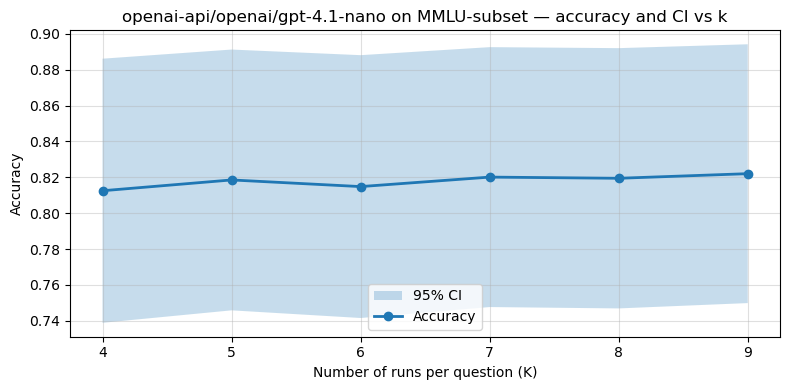

In [15]:
k_values    = [4, 5, 6, 7, 8, 9]
accuracies    = []
ci_lowers     = []
ci_uppers     = []

for k in k_values:    
    logs: List[EvalLog] = eval(
        mmlu_subset(MY_SUBSET),
        model=MODEL_A,
        epochs=k,    # Количество повторов каждого вопроса
    )
   
    df = log_to_df(logs[0])
    
    ci_lower, acc, ci_upper = ci_accuracy(df, ci=0.95)
    
    accuracies.append(acc)
    ci_lowers.append(ci_lower)
    ci_uppers.append(ci_upper)
        
plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?
2. Does more K change your estimate of the model's accuracy, or just your confidence in it?
3. What does this tell you about how to allocate your evaluation budget?

**Your answer:**

1. I ran these evals on ChatGPT-4.1-nano. I can barely see any narrowing — the CIs seemed to be very stable even after 4 epochs per question. Maybe it would be more useful to visualize how the CI shrinks in percentage with the addition of new epochs, or the model I used is just good enough on this subset and is pretty stable. In my opinion, after 4 epochs for this particular case, there is no real need to run another epoch.

2. Depending on model stability, increasing the number of epochs can change for the better both the estimate of the model's accuracy and our confidence in it. With a smaller number of K, our estimate may be incorrect due to random fluctuations in model answers — so I would say both parameters are affected by increasing the number of epochs, but after a certain number of epochs, the estimate stabilizes and the confidence interval continues to shrink.

3. I do not think that global conclusions can be drawn from the data obtained. Nevertheless, I can say that for strong models and benchmarks that are similar in difficulty level to MMLU, there is no need to run more than 4–5 epochs — it will cost money for researchers but will barely give us valuable information.

## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

Output()

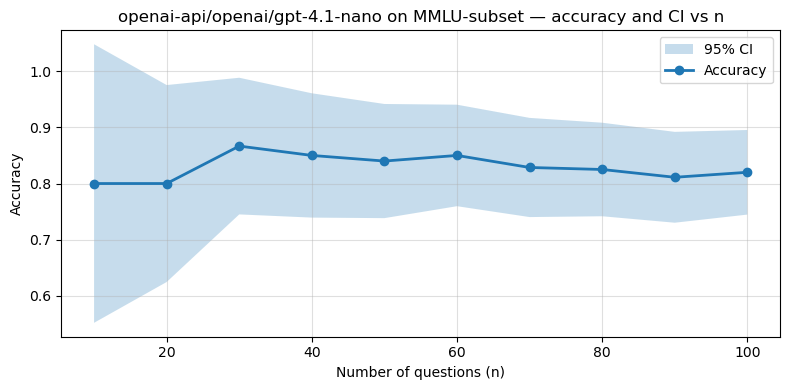

In [16]:
question_ids  = list(range(1, len(MY_SUBSET) + 1))
dataset_sizes = range(10, len(question_ids) + 1, 10)
accuracies    = []
ci_lowers     = []
ci_uppers     = []

# YOUR CODE HERE
logs: List[EvalLog] = eval(
        mmlu_subset(MY_SUBSET),
        model=MODEL_A,
)
   
df = log_to_df(logs[0])

for s in dataset_sizes:
    filtered_df = df[df['id'].between(1, s)]
    ci_lower, acc, ci_upper = ci_accuracy(filtered_df, ci=0.95)
    accuracies.append(acc)
    ci_lowers.append(ci_lower)
    ci_uppers.append(ci_upper)

plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. At what n does the accuracy line start to feel stable?
2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region?
3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

**Your answer:**

1.  Empirically, after around 90 questions the accuracy starts to feel quite stable. The main drop (the largest changes in the estimate) is over at approximately 80 questions, and beyond 90 questions the line becomes flat with only minor fluctuations.

2. MY_SUBSET consists of 108 questions — so I think it is pretty reliable, but on the edge of the reliable region, so adding 10–20 questions would make it better.

3. Number of questions is way more significant for accuracy than number of epochs — while for 4 and more epochs the CI is barely shrinking, the difference between the CI for 20 and 90 questions is drastic.


## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.


## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [17]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"
    
    alternative = "two-sided" if two_tailed else "greater"
    
    mean_diff = np.mean(scores1) - np.mean(scores2)
    se_paired = np.sqrt(np.sum((scores1 - scores2 - mean_diff)**2)/((len(scores1) - 1)*len(scores1)))
    if np.isclose(se_paired, 0):
        if np.isclose(mean_diff, 0):
            p_value = 1.0
        else:
            p_value = 0.0
        return p_value, mean_diff, bool(p_value < alpha)
    t = mean_diff/se_paired
    p_value = 2 * (1 - stats.t.cdf(abs(t), (len(scores1) - 1)))    
    
    return p_value, mean_diff, bool(p_value < alpha)


def compare_models_paired(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [18]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1,2,3]), np.array([1,2,3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1,1,1,1,1]), np.array([0,0,0,0,0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


In [19]:
p_value, mean_diff, is_significant = compare_models_paired(
        model_a= MODEL_B,
        model_b=MODEL_A,
        dataset=MY_SUBSET,
        alpha=0.05,
        two_tailed=True,  # Проверяем, отличаются ли модели вообще
        epochs_a=1,
        epochs_b=1
    )
print("p_value: ", p_value)
print("mean_diff: ", mean_diff)
print("Is significant - ", is_significant)

Output()

  Running openai-api/qwen/qwen3.5-flash ...


Output()

  Running openai-api/openai/gpt-4.1-nano ...


p_value:  0.03235648930502433
mean_diff:  0.09259259259259256
Is significant -  True


---
1. Write down the p-value and the mean difference you got.
2. Is the gap significant? Is it large enough to matter in practice?
3. What would change your conclusion: more questions, a different subject, or a different model pair?

**Your answer:**
1. I ran 2 comparison test gpt-4.1-nano with gemini-3.1-flash-lite-preview and with qwen3.5-flash. In the forst case i got

   p_value = 1.5543122344752192e-15

   mean_diff = -0.5277777777777777

   In the second case i got

   p_value = 0.03235648930502433

   mean_diff = 0.09259259259259256
   
2. For the first model pair the gap is both statistically significant and practically very large (mean difference ≈ –0.53, about 53 percentage points). This would absolutely matter in any real-world application — one model is much stronger on this subset.

   For the second pair the gap is still statistically significant (p ≈ 0.032 < 0.05), but the practical significance is debatable. The mean difference is about 0.093 (roughly 9%). Whether this matters depends on the use case: for high-stakes applications (like legal field as in MY_SUBSET), 9% is meaningful; for casual chatbots or simple classification tasks, it might be negligible. However, with a p-value this close to 0.05, the result is fragile — I would not make strong claims without more data.

   
4. The different model pair is the most significant factor in my opinion — the first pair shows a massive gap, while the second pair is borderline. Changing the model pair would completely alter the conclusion

   For the second pair specifically (p ≈ 0.032, 9% difference), both more questions and a different subject could change the conclusion. More questions (larger n) would reduce the confidence interval width and provide a more stable estimate of the true difference. The p-value could either drop below 0.01 (if the 9% gap is real) or rise above 0.05 (if the gap was a statistical fluctuation). A different subject (another MMLU subset) could yield a very different mean difference — models often excel in some domains but not others. The gap might change in any direction.

## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Implement `ci_accuracy_for_difference` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [20]:
def ci_accuracy_for_difference(scores1: np.ndarray, scores2: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    """
    mean_diff = np.mean(scores1) - np.mean(scores2)
    se_paired = np.sqrt(np.sum((scores1 - scores2 - mean_diff)**2)/((len(scores1) - 1)*len(scores1)))
    z = norm.ppf(1 - (1 - ci) / 2)
    margin = z * se_paired
    lower_bound = mean_diff - margin
    upper_bound = mean_diff + margin
    return (lower_bound, mean_diff, upper_bound)

In [22]:
scores_a = run_and_get_scores(MODEL_A, MY_SUBSET)
scores_b = run_and_get_scores(MODEL_B, MY_SUBSET)
   
ci_lower, acc, ci_upper = ci_accuracy_for_difference(scores_a, scores_b, ci=0.95)
print("CI_lower: ", ci_lower)
print("Accuracy: ", acc)
print("CI_upper: ", ci_upper)

Output()

  Running openai-api/openai/gpt-4.1-nano ...


Output()

  Running openai-api/qwen/qwen3.5-flash ...


CI_lower:  -0.15215921074457367
Accuracy:  -0.08333333333333337
CI_upper:  -0.014507455922093085


---
1. Write down the interval. Does it contain zero?
2. How does this relate to the significance test in Assignment 5 — do they tell the same story?
3. Which result is more informative — the p-value or the interval? Why?

**Your answer:**  
1. Again i ran 2 pairs as in previous assignment.\
   For pair gpt-4.1-nano and gemini-3.1-flash-lite-preview i got CI:  
   CI_lower = 0.4294011103848068  
   Accuracy = 0.537037037037037  
   CI_upper = 0.6446729636892672  
   CI don't contain zero
   
   for pair gpt-4.1-nano and qwen3.5-flash i got:  
   CI_lower:  -0.15215921074457367  
   Accuracy:  -0.08333333333333337  
   CI_upper:  -0.014507455922093085
   CI don't contain zero
2. Yes, both CIs tell exactly the same story as the p-values from Assignment 5. For the first pair: p-value was extremely small (~1.55e-15), and now the 95% CI is [0.43, 0.64] — entirely above zero. Both indicate a highly significant difference. For the second pair: p-value was 0.032 (< 0.05), and now the 95% CI is [-0.152, -0.0145] — entirely below zero. Again, both indicate statistical significance. A CI that does not contain zero is equivalent to rejecting the null hypothesis at α = 0.05 (for a two-sided test). So the two methods are perfectly consistent here.
3. The confidence interval is more informative than the p-value alone. P-value only provides you the level of significance, while observing the CI can show you which model is actually stronger, the magnitude of the difference (~53% for the first pair, ~8.3% for the second), and precision (width of the interval — narrow for the first pair, wider for the second

## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [23]:
def estimate_variance_components(
    logs_a: List[EvalLog],
    logs_b: List[EvalLog],
) -> dict:
    """
    Estimate omega2, sigma2_a, sigma2_b from two EvalLog objects (see ss5 of the paper).

    Both logs must cover the same set of questions. Use epochs >= 2 so that
    within-question variance can be estimated.

    Returns dict with keys 'omega2', 'sigma2_a', 'sigma2_b'.
    """

    df_a = log_to_df(logs_a[0])
    df_b = log_to_df(logs_b[0])

    sigma2_a = (
        df_a.groupby('id')['score']
        .var(ddof=1)  
        .mean()       
    )
    sigma2_b = (
        df_b.groupby('id')['score']
        .var(ddof=1)  
        .mean()       
    )
    
    omega2 = (df_a.groupby('id')['score'].mean() - df_b.groupby('id')['score'].mean()).var(ddof=1)
    
    return {
        "omega2":   omega2,
        "sigma2_a": sigma2_a,
        "sigma2_b": sigma2_b,
    }


def minimum_detectable_effect(
    n: int,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """MDE for a paired model comparison (Eq. 10 in the paper)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * np.sqrt(
        (omega2 + sigma2_a / ka + sigma2_b / kb) / n
    ))

In [24]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Output()

Running pilot evals ...


Output()

omega2  = 0.2310
sigma2_A = 0.0000
sigma2_B = 0.0333

With n=108 questions -> MDE = 13.9%
(smallest gap detectable at 80% power, alpha=0.05)


---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?
2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

**Your answer:**
1. For pair gpt-4.1-nano and gemini-3.1-flash-lite-preview i got:
   omega2  = 0.3738
   sigma2_A = 0.0000
   sigma2_B = 0.0667
   With n=108 questions -> MDE = 17.9% (smallest gap detectable at 80% power, alpha=0.05)
   In this case an 18% accuracy gap is huge — in most real-world applications, such a difference would be very meaningful. However, note that the actual observed gap in Assignment 5 was about 53%, which is much larger than the MDE. So the MDE tells me that my test is sensitive enough to catch even much smaller differences than the one I actually observed.
   For the pair gpt-4.1-nano and qwen3.5-flash i got:
   omega2  = 0.2310
   sigma2_A = 0.0000
   sigma2_B = 0.0333
   With n=108 questions -> MDE = 13.9% (smallest gap detectable at 80% power, alpha=0.05)
   In this case an 14% accuracy gap is also quite bifg even though smaller than in first case. A 14% gap would be meaningful in many contexts, but my test cannot reliably detect gaps smaller than that.
3. For the first pair the actual observed gap in Assignment 5 was about 53%, which is much larger than the MDE. So the MDE tells me that my test is sensitive enough to catch even much smaller differences than the one I actually observed.  
For the second pair the observed gap was about 9.3%, but the MDE is 13.9%, which is larger. This means my experiment was underpowered to detect the true effect size. The earlier significant result (p = 0.032) should be treated with caution. The experiment does not have enough power to reliably detect a gap as small as 9.3%. To be confident, I would need either more questions (larger n) or a more stable model (lower variance).

## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [26]:
# --- Assignment 7 -----------------------------------------------------------
def required_sample_size(
    delta: float,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """Minimum number of questions needed to detect `delta` at the given power."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power) 
    params = estimate_variance_components(logs_a, logs_b)
    n = (z_alpha + z_beta)**2 * (omega2 + sigma2_a/ka + sigma2_b/kb) / delta**2
    return n


# =================================== TESTS ===================================
n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

Questions needed to detect delta=5%: 829.7387147740466
Round-trip check passed!


In [27]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2)

params = estimate_variance_components(logs_a, logs_b)

n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")
n_needed = required_sample_size(delta=0.1, **params)
print(f"Questions needed to detect delta=10%: {n_needed}")

Output()

Running pilot evals ...


Output()

Questions needed to detect delta=5%: 559.120612436498
Questions needed to detect delta=10%: 139.7801531091245


---
1. How many questions do you need to detect a 5% gap? A 10% gap?
2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

**Your answer:**
1. For pair gpt-4.1-nano and gemini-3.1-flash-lite-preview i got:  
   Questions needed to detect delta=5%: 1112.5359125011944
   Questions needed to detect delta=10%: 278.1339781252986  
   For the pair gpt-4.1-nano and qwen3.5-flash i got:
   Questions needed to detect delta=5%: 559.120612436498
   Questions needed to detect delta=10%: 139.7801531091245
3.  In the first case — no, we need many more questions. For a 5% gap, even 10 times more questions would not be enough.  
In the second case, my subset is still not enough (I suspected this in Assignment 4.2 but wasn't sure), but it is closer to the borderline for detecting a 10% gap.

## Assignment 9: Compare a model with itself: baseline vs chain-of-thought

The `multiple_choice()` solver we have used so far prompts the model to answer
directly. inspect_ai also provides a `chain_of_thought` that asks the model
to reason step by step before giving its final answer.

Using the paired comparison infrastructure from Section 7, evaluate the same model
twice on the same subset — once with the default solver and once with
`chain_of_thought` — and test whether the difference in accuracy is statistically
significant. Does reasoning help? Is the effect consistent across subjects?

In [29]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, solver=multiple_choice(cot=True), epochs=2)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Output()

Running pilot evals ...


Output()

omega2  = 0.1316
sigma2_A = 0.0185
sigma2_B = 0.0880

With n=108 questions -> MDE = 13.2%
(smallest gap detectable at 80% power, alpha=0.05)


---
1. Does chain-of-thought help? By how much, and is it significant?
2. Does the result surprise you? What might explain it?
3. Would you expect the same pattern on a different subject?

**Your answer:**
1. No, chain-of-thought does not help — it actually hurts performance. The accuracy without CoT is 0.815 (81.5%), while with CoT it drops to 0.736 (73.6%), a difference of −7.9 percentage points (CoT is worse by about 8%). However, the MDE for this experiment is 13.2%, meaning that with 108 questions, I can only reliably detect differences larger than 13.2%. Since the observed gap of 7.9% is smaller than the MDE, this difference is not statistically significant at 80% power. In other words, the experiment is underpowered to detect a 7.9% drop. I cannot conclude that CoT significantly hurts performance — the observed difference could be due to random noise. To get a definitive answer, I would need more questions (larger n) to reduce the MDE below 7.9%.
2. Yes, it does surprise me — I thought CoT would improve results. But analyzing the CoT logs, I discovered that the model starts to get confused in the middle of the reasoning steps; that might explain the outcome. Also, the chain-of-thought condition has higher variance across questions. The omega² of 0.1316 indicates that only about 13% of the total variance is due to systematic differences between solvers; most variance comes from randomness. This suggests that CoT does not consistently outperform or underperform the default solver across all questions — the effect contains a lot of noise.  
3.After these results, I would say that on a different MMLU subject, the variance components and the observed gap could be quite different. I would expect CoT to show a positive effect on harder, reasoning-heavy subjects, and possibly a negative effect on easy or purely factual subjects. But I am not quite sure.

## Bonus assignment: Clustered Standard Errors

Some benchmarks contain groups of related questions — for example, several questions
about the same passage in reading comprehension tasks like DROP or RACE. In such cases
the standard CLT confidence interval is anti-conservative: questions within a group are
correlated, so the effective sample size is smaller than n. Miller (2024) addresses this
with clustered standard errors (§2.2).

Using a reading comprehension benchmark of your choice, implement the clustered
confidence interval (Eq. 4 from the paper) and compare it against the naive CLT interval.
How much wider is the clustered interval? Does the difference depend on the benchmark?
Then compare two models on the same benchmark using the clustered paired standard error
(Eq. 8) — does the conclusion about which model is better change compared to the
naive paired test?